# Lib

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

import cv2
import os


2025-12-04 19:31:45.369009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764876705.573351      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764876705.625412      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import os, shutil
import random
import numpy as np
import pandas as pd
import cv2
import skimage
import matplotlib.pyplot as plt
import skimage.segmentation
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')


# Tiền xử lý dữ liệu

## Load data

In [3]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from tqdm import tqdm

labels = ['Pneumonia', 'Normal', 'Covid19']
img_size = 224

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        img_files = os.listdir(path)

        print(f"\nLoading {label} ({len(img_files)} images)...")

        # tqdm hiển thị progress bar
        for img in tqdm(img_files):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data

# Load data (only PNEUMONIA and NORMAL, COVID19 is excluded)
train = get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/train")
val = get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/val")

# Trộn ảnh để tránh hiện tượng mô hình học theo thứ tự ảnh
train = shuffle(train, random_state=42)
val = shuffle(val, random_state=42)

# Đưa ảnh vào dạng NumPy - Reshape thành (N, 224, 224, 1) → ảnh grayscale 1 kênh
x_train = np.array([i[0] for i in train]).reshape(-1, img_size, img_size, 1)
y_train = np.array([i[1] for i in train])

x_val = np.array([i[0] for i in val]).reshape(-1, img_size, img_size, 1)
y_val = np.array([i[1] for i in val])

# Normalize the pixel values to be between 0 and 1
x_train = x_train / 255.0
x_val = x_val / 255.0

# Print shapes to verify everything is correct
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_val.shape)
print("Test labels shape:", y_val.shape)

# Check class distribution
print("\nClass distribution in training set:")
print(f"PNEUMONIA: {np.sum(y_train == 0)}")
print(f"NORMAL: {np.sum(y_train == 1)}")
print(f"Covid19: {np.sum(y_train == 2)}")

print("\nClass distribution in val set:")
print(f"PNEUMONIA: {np.sum(y_val == 0)}")
print(f"NORMAL: {np.sum(y_val == 1)}")
print(f"Covid19: {np.sum(y_val == 2)}")


Loading Pneumonia (7912 images)...


100%|██████████| 7912/7912 [01:14<00:00, 106.28it/s]



Loading Normal (10153 images)...


100%|██████████| 10153/10153 [01:38<00:00, 102.94it/s]



Loading Covid19 (3353 images)...


...


Loading Normal (634 images)...


100%|██████████| 634/634 [00:06<00:00, 98.67it/s] 



Loading Covid19 (209 images)...


100%|██████████| 209/209 [00:02<00:00, 83.17it/s] 


Training data shape: (21418, 224, 224, 1)
Training labels shape: (21418,)
Test data shape: (1337, 224, 224, 1)
Test labels shape: (1337,)

Class distribution in training set:
PNEUMONIA: 7912
NORMAL: 10153
Covid19: 3353

Class distribution in val set:
PNEUMONIA: 494
NORMAL: 634
Covid19: 209


## Hiện thị mẫu

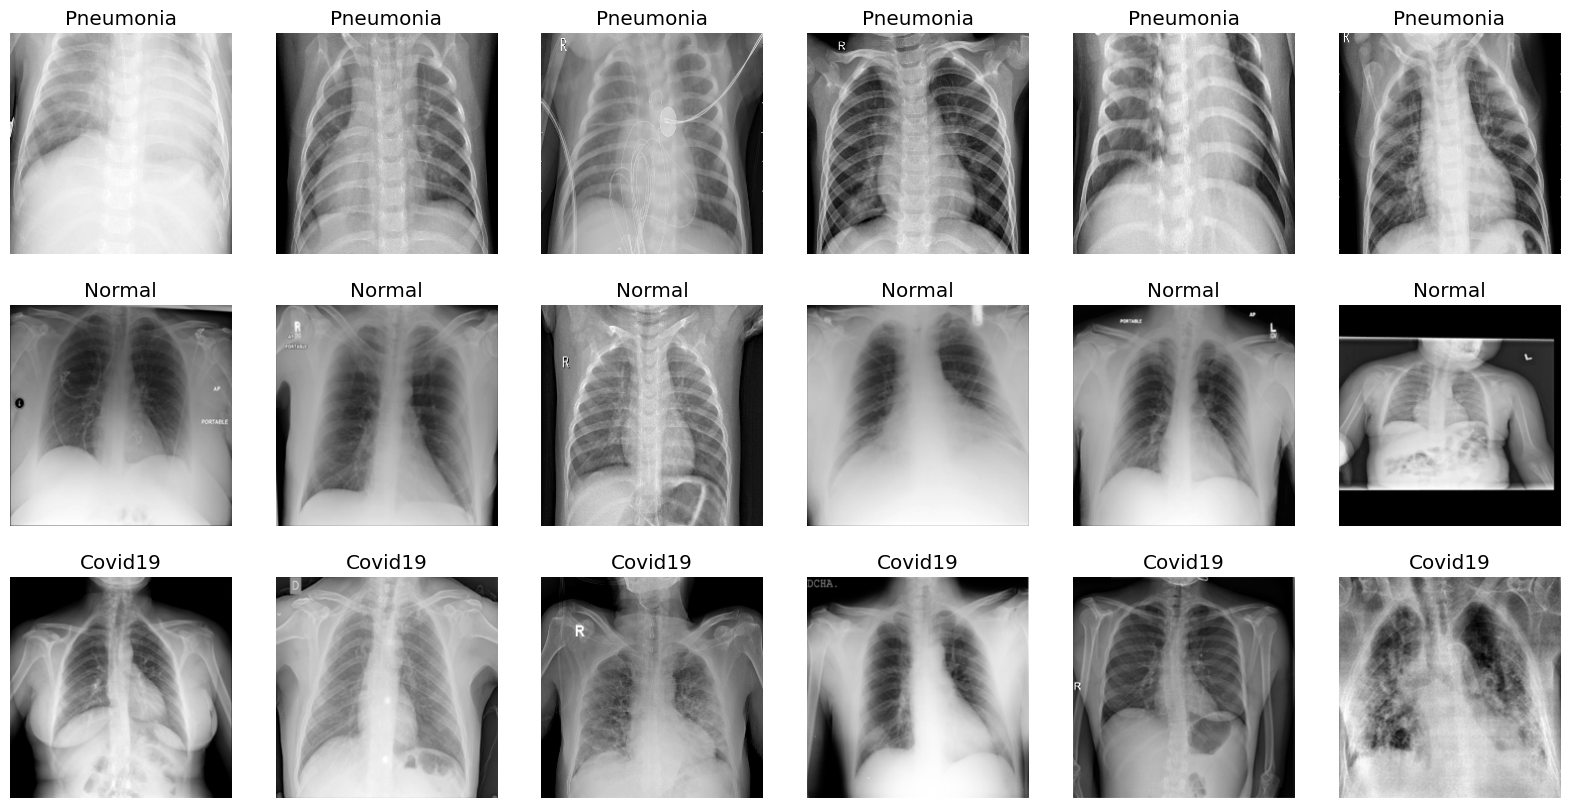

In [4]:
def show_samples_per_class(images, labels, class_names, samples_per_class=6):
    plt.figure(figsize=(20, 10))
    index = 1
    
    for class_id, class_name in enumerate(class_names):
        count = 0
        for i in range(len(labels)):
            if labels[i] == class_id:
                plt.subplot(len(class_names), samples_per_class, index)
                plt.imshow(images[i].reshape(img_size, img_size), cmap='gray')
                plt.title(class_name)
                plt.axis("off")
                index += 1
                count += 1
                if count == samples_per_class:
                    break
                    
    plt.show()

show_samples_per_class(x_train, y_train, labels)


## Tăng cường ảnh

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range = 30,
        zoom_range = 0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip = True,
        vertical_flip=False
)
datagen.fit(x_train)

# xây dựng mô hình

In [6]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow as tf

def conv_block(x, filters, stride=1):
    f1, f2, f3 = filters

    shortcut = x

    # 1x1
    x = Conv2D(f1, (1,1), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # 3x3
    x = Conv2D(f2, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # 1x1
    x = Conv2D(f3, (1,1), padding='same')(x)
    x = BatchNormalization()(x)

    # shortcut downsample
    if stride != 1 or shortcut.shape[-1] != f3:
        shortcut = Conv2D(f3, (1,1), strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # add
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


def identity_block(x, filters):
    return conv_block(x, filters, stride=1)
def build_resnet50(input_shape=(224,224,1), num_classes=3):

    inputs = Input(input_shape)

    # convert to 3 channels
    x = Concatenate()([inputs, inputs, inputs])

    # ===== STEM =====
    x = Conv2D(64, (7,7), strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPool2D((3,3), strides=2, padding='same')(x)

    # ===== STAGE 1 ===== (3 blocks)
    x = conv_block(x, [64, 64, 256], stride=1)
    for _ in range(2):
        x = identity_block(x, [64, 64, 256])

    # ===== STAGE 2 ===== (4 blocks)
    x = conv_block(x, [128, 128, 512], stride=2)
    for _ in range(3):
        x = identity_block(x, [128, 128, 512])

    # ===== STAGE 3 ===== (6 blocks)
    x = conv_block(x, [256, 256, 1024], stride=2)
    for _ in range(5):
        x = identity_block(x, [256, 256, 1024])

    # ===== STAGE 4 ===== (3 blocks)
    x = conv_block(x, [512, 512, 2048], stride=2)
    for _ in range(2):
        x = identity_block(x, [512, 512, 2048])

    # ===== HEAD =====
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


model = build_resnet50()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1764876953.101976      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224, 224,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      4,160 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     16,640 │ max_pooling2d[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,638,339 (93.99 MB)

 Trainable params: 24,585,219 (93.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

# Huấn luyện model
Tối ưu bằng Adam optimizer, learning rate = 1e-4.

Loss function: Categorical Cross-Entropy.


Batch size: 32 – 64.

Sử dụng Early Stopping để tránh overfitting.

Model Checkpoint để lưu mô hình có hiệu suất tốt nhất.


In [7]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.00000001)


In [8]:


checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [9]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[learning_rate_reduction, checkpoint]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1764876989.938921      62 service.cc:148] XLA service 0x7ec1dc002e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764876989.939811      62 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764876994.527656      62 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764877019.694285      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.6908 - loss: 0.8032
Epoch 1: val_accuracy improved from -inf to 0.36948, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 187s 374ms/step - accuracy: 0.6910 - loss: 0.8026 - val_accuracy: 0.3695 - val_loss: 7.0166 - learning_rate: 1.0000e-04
Epoch 2/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8435 - loss: 0.3983
Epoch 2: val_accuracy improved from 0.36948 to 0.73897, saving model to best_model.h5


...

335/335 ━━━━━━━━━━━━━━━━━━━━ 95s 282ms/step - accuracy: 0.9627 - loss: 0.1099 - val_accuracy: 0.9604 - val_loss: 0.1225 - learning_rate: 9.0000e-06
Epoch 16/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9605 - loss: 0.1124
Epoch 16: val_accuracy did not improve from 0.96036
335/335 ━━━━━━━━━━━━━━━━━━━━ 138s 271ms/step - accuracy: 0.9606 - loss: 0.1124 - val_accuracy: 0.9237 - val_loss: 0.2295 - learning_rate: 9.0000e-06
Epoch 17/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9628 - loss: 0.1009
Epoch 17: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.

Epoch 17: val_accuracy did not improve from 0.96036
335/335 ━━━━━━━━━━━━━━━━━━━━ 91s 270ms/step - accuracy: 0.9628 - loss: 0.1009 - val_accuracy: 0.9581 - val_loss: 0.1159 - learning_rate: 9.0000e-06
Epoch 18/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9633 - loss: 0.1033
Epoch 18: val_accuracy did not improve from 0.96036
335/335 ━━━━━━━━━━━━━━━━━━━━ 91s 270ms/step - accurac

335/335 ━━━━━━━━━━━━━━━━━━━━ 92s 273ms/step - accuracy: 0.9652 - loss: 0.0996 - val_accuracy: 0.9701 - val_loss: 0.0953 - learning_rate: 2.7000e-06
Epoch 20/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9701 - loss: 0.0910
Epoch 20: val_accuracy did not improve from 0.97008
335/335 ━━━━━━━━━━━━━━━━━━━━ 91s 270ms/step - accuracy: 0.9701 - loss: 0.0910 - val_accuracy: 0.9619 - val_loss: 0.1112 - learning_rate: 2.7000e-06
Epoch 21/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9645 - loss: 0.0979
Epoch 21: ReduceLROnPlateau reducing learning rate to 8.099999604382901e-07.

Epoch 21: val_accuracy did not improve from 0.97008
335/335 ━━━━━━━━━━━━━━━━━━━━ 91s 270ms/step - accuracy: 0.9645 - loss: 0.0978 - val_accuracy: 0.9686 - val_loss: 0.0902 - learning_rate: 2.7000e-06
Epoch 22/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9677 - loss: 0.0935
Epoch 22: val_accuracy improved from 0.97008 to 0.97083, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 92s 273ms/step - accuracy: 0.9677 - loss: 0.0935 - val_accuracy: 0.9708 - val_loss: 0.0884 - learning_rate: 8.1000e-07
Epoch 23/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9666 - loss: 0.0998
Epoch 23: val_accuracy did not improve from 0.97083
335/335 ━━━━━━━━━━━━━━━━━━━━ 90s 269ms/step - accuracy: 0.9666 - loss: 0.0997 - val_accuracy: 0.9678 - val_loss: 0.0906 - learning_rate: 8.1000e-07
Epoch 24/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9681 - loss: 0.0904
Epoch 24: val_accuracy improved from 0.97083 to 0.97158, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 92s 273ms/step - accuracy: 0.9681 - loss: 0.0904 - val_accuracy: 0.9716 - val_loss: 0.0872 - learning_rate: 8.1000e-07
Epoch 25/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9680 - loss: 0.0931
Epoch 25: val_accuracy improved from 0.97158 to 0.97307, saving model to best_model.h5


335/335 ━━━━━━━━━━━━━━━━━━━━ 92s 273ms/step - accuracy: 0.9680 - loss: 0.0931 - val_accuracy: 0.9731 - val_loss: 0.0856 - learning_rate: 8.1000e-07
Epoch 26/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9682 - loss: 0.0907
Epoch 26: val_accuracy did not improve from 0.97307
335/335 ━━━━━━━━━━━━━━━━━━━━ 90s 269ms/step - accuracy: 0.9682 - loss: 0.0907 - val_accuracy: 0.9708 - val_loss: 0.0889 - learning_rate: 8.1000e-07
Epoch 27/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9683 - loss: 0.0943
Epoch 27: ReduceLROnPlateau reducing learning rate to 2.4299998813148704e-07.

Epoch 27: val_accuracy did not improve from 0.97307
335/335 ━━━━━━━━━━━━━━━━━━━━ 90s 269ms/step - accuracy: 0.9683 - loss: 0.0943 - val_accuracy: 0.9708 - val_loss: 0.0893 - learning_rate: 8.1000e-07
Epoch 28/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9719 - loss: 0.0875
Epoch 28: val_accuracy did not improve from 0.97307
335/335 ━━━━━━━━━━━━━━━━━━━━ 90s 269ms/step - accuracy

In [10]:
print("Loss of the model is - " , model.evaluate(x_val,y_val)[0])
print("Accuracy of the model is - " , model.evaluate(x_val,y_val)[1]*100 , "%")


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9672 - loss: 0.0983
Loss of the model is -  0.08795083314180374
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9672 - loss: 0.0983
Accuracy of the model is -  97.08302021026611 %


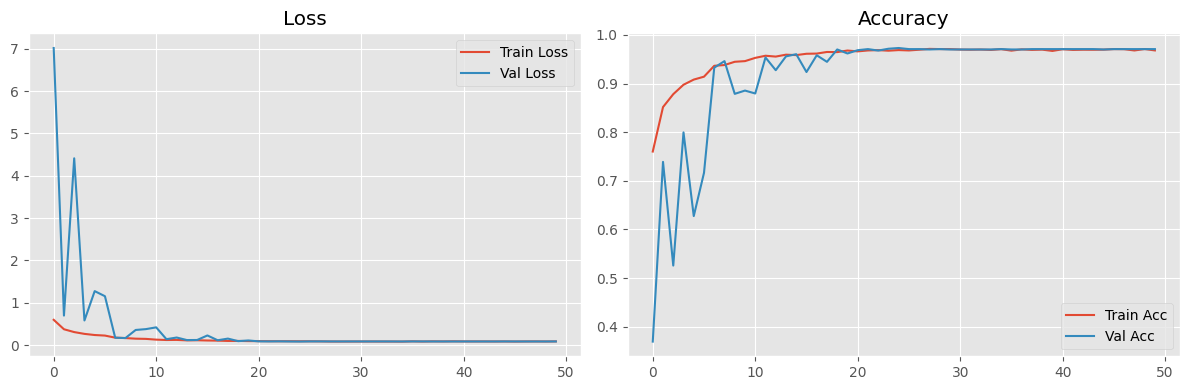

In [11]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# Đánh giá mô hình

In [12]:
from sklearn.metrics import accuracy_score

y_prob = model.predict(x_val)

y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_val, y_pred)

print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step
Accuracy: 0.9708 (97.08%)


## Accuracy, Precision, Recall, F1-score.

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

label_names = ['Pneumonia', 'Normal', 'Covid19']



precision, recall, f1, support = precision_recall_fscore_support(
    y_val, y_pred, average=None, zero_division=0
)

acc_per_class = recall

print("\n" + "="*75)
print("CHI TIẾT METRICS CHO TỪNG CLASS")
print("="*75)
print(f"{'Class':<12} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Accuracy':<10} {'Support':<8}")
print("-" * 75)

for i in range(3):
    print(f"{label_names[i]:<12} {precision[i]:<10.4f} {recall[i]:<10.4f} "
          f"{f1[i]:<10.4f} {acc_per_class[i]:<10.4f} {support[i]:<8}")

# Macro averages
macro_precision = np.mean(precision)
macro_recall = np.mean(recall)
macro_f1 = np.mean(f1)
macro_acc = np.mean(acc_per_class)

print("-" * 75)
print(f"{'Macro Avg':<12} {macro_precision:<10.4f} {macro_recall:<10.4f} "
      f"{macro_f1:<10.4f} {macro_acc:<10.4f}")



CHI TIẾT METRICS CHO TỪNG CLASS
Class        Precision  Recall     F1-Score   Accuracy   Support 
---------------------------------------------------------------------------
Pneumonia    0.9795     0.9676     0.9735     0.9676     494     
Normal       0.9598     0.9795     0.9696     0.9795     634     
Covid19      0.9851     0.9522     0.9684     0.9522     209     
---------------------------------------------------------------------------
Macro Avg    0.9748     0.9664     0.9705     0.9664    


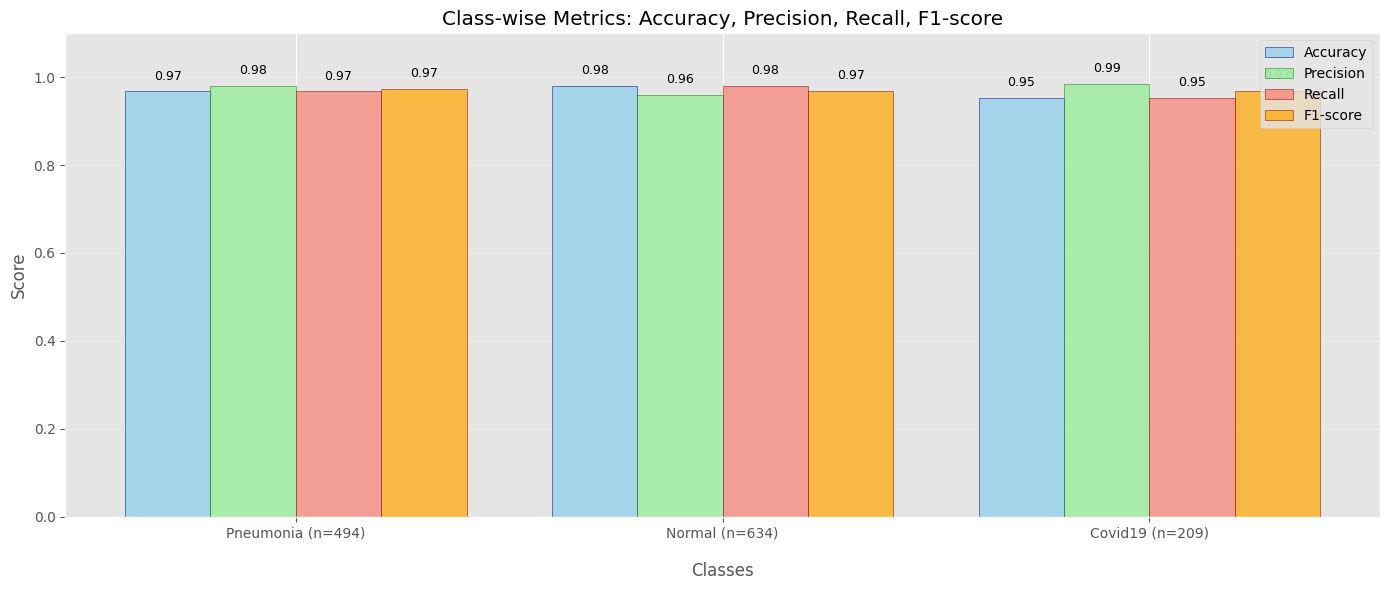

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_classwise_metrics(y_true, y_pred, class_names):
    """
    Vẽ biểu đồ class-wise metrics: Accuracy, Precision, Recall, F1-score
    """
    n_classes = len(class_names)
    
    # Tính metrics cho từng lớp
    accuracies = []
    precisions = precision_score(y_true, y_pred, average=None, zero_division=0)
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    class_counts = []
    for i in range(n_classes):
        class_mask = (y_true == i)
        class_pred = y_pred[class_mask]
        class_true = y_true[class_mask]
        acc = accuracy_score(class_true, class_pred) if len(class_true) > 0 else 0
        accuracies.append(acc)
        class_counts.append(len(class_true))
    
    # Vẽ biểu đồ
    x = np.arange(n_classes)
    width = 0.2  # độ rộng mỗi cột

    plt.figure(figsize=(14,6))
    plt.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='skyblue', edgecolor='navy', alpha=0.7)
    plt.bar(x - 0.5*width, precisions, width, label='Precision', color='lightgreen', edgecolor='green', alpha=0.7)
    plt.bar(x + 0.5*width, recalls, width, label='Recall', color='salmon', edgecolor='darkred', alpha=0.7)
    plt.bar(x + 1.5*width, f1_scores, width, label='F1-score', color='orange', edgecolor='darkred', alpha=0.7)
    
    # Thêm nhãn giá trị lên từng cột
    for i in range(n_classes):
        plt.text(x[i] - 1.5*width, accuracies[i]+0.02, f'{accuracies[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] - 0.5*width, precisions[i]+0.02, f'{precisions[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 0.5*width, recalls[i]+0.02, f'{recalls[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 1.5*width, f1_scores[i]+0.02, f'{f1_scores[i]:.2f}', ha='center', va='bottom', fontsize=9)

    xtick_labels = [f"{name} (n={count})\n" for name, count in zip(class_names, class_counts)]
    plt.xticks(x, xtick_labels, rotation=0, ha='center')
    plt.ylim(0, 1.1)
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Class-wise Metrics: Accuracy, Precision, Recall, F1-score')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return accuracies, precisions, recalls, f1_scores, class_counts

# Sử dụng:
accuracies, precisions, recalls, f1_scores, counts = plot_classwise_metrics(y_val, y_pred, label_names)


## Confusion Matrix

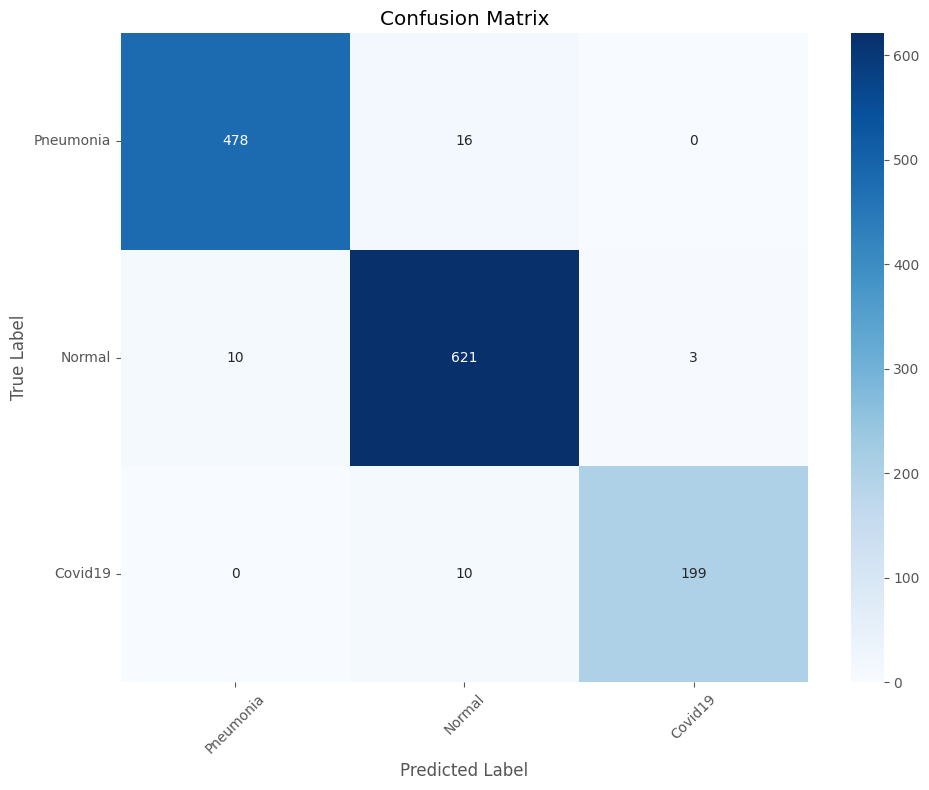

In [15]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(y_val, y_pred, label_names)

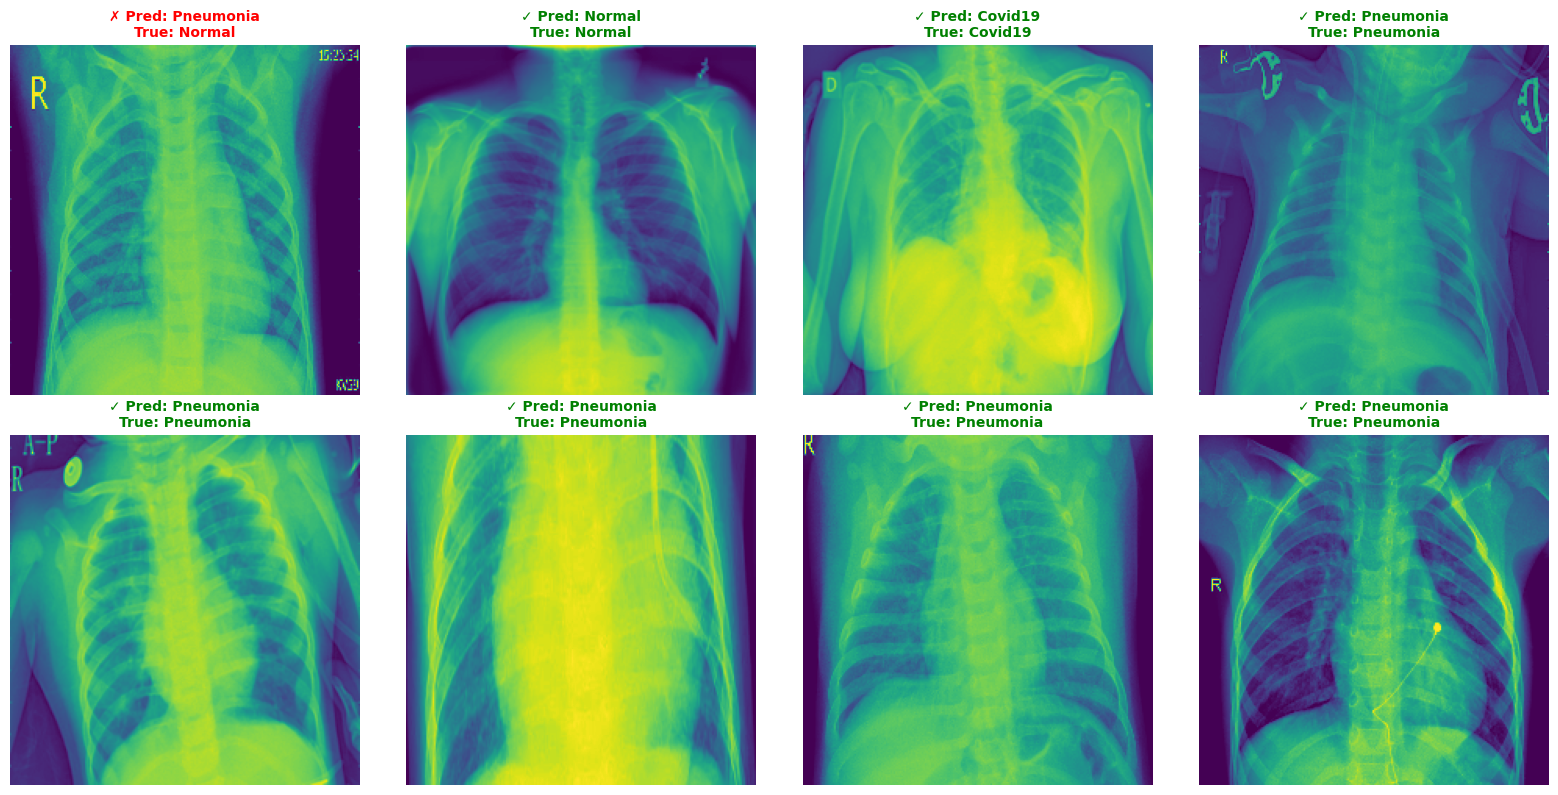

In [16]:
def display_predictions(images, true_labels, pred_labels, class_names, n_samples=8):
    """Hiển thị ảnh với nhãn dự đoán và đánh dấu đúng/sai"""

    plt.figure(figsize=(16, 8))

    for i in range(n_samples):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i])
        plt.axis('off')

        true_label = class_names[true_labels[i]]
        pred_label = class_names[pred_labels[i]]

        # Đánh dấu đúng (✓) hoặc sai (✗)
        if true_labels[i] == pred_labels[i]:
            color = 'green'
            mark = '✓'
        else:
            color = 'red'
            mark = '✗'

        plt.title(f"{mark} Pred: {pred_label}\nTrue: {true_label}",
                 color=color, fontsize=10, weight='bold')

    plt.tight_layout()
    plt.show()

display_predictions(x_val, y_val, y_pred, label_names, 8)


## Grad-CAM

In [17]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Tạo grad_model lấy output conv cuối + output dự đoán
# # grad_model = Model([model.inputs], [model.get_layer("last_conv").output, model.output])
# grad_model = Model(
#     [model.inputs],
#     [model.get_layer("conv2d_51").output, model.output]
# )


# def grad_cam(input_image, true_label=None):
#     """
#     input_image: shape (1,H,W,C)
#     true_label: nếu muốn dùng nhãn thật
#     """
#     with tf.GradientTape() as tape:
#         conv_out, preds = grad_model(input_image)
#         class_idx = tf.argmax(preds[0])
#         if true_label is not None:
#             class_idx = tf.constant(true_label)
#         loss = preds[:, class_idx]

#     grads = tape.gradient(loss, conv_out)
#     pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))  # global average pooling
#     conv_out = conv_out[0]  # bỏ batch
#     heatmap = tf.reduce_sum(tf.multiply(conv_out, pooled_grads), axis=-1)
#     heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
#     heatmap = tf.image.resize(heatmap[...,None], (224,224)).numpy()[...,0]
#     return heatmap, int(class_idx)


In [18]:
# import matplotlib.pyplot as plt
# import numpy as np

# num_classes = 3
# num_per_class = 3
# class_names = ['Pneumonia', 'Normal', 'Covid19']

# # Duyệt từng class
# for cls in range(num_classes):
#     # Lấy index của các ảnh thuộc class cls
#     idxs = np.where(y_val == cls)[0][:num_per_class]  # 3 ảnh đầu tiên
    
#     plt.figure(figsize=(12, 4*num_per_class))
    
#     for i, k in enumerate(idxs):
#         img = x_val[k][np.newaxis, ...]  # batch dimension
#         hm, cls_idx = grad_cam(img)
        
#         # Ảnh gốc
#         plt.subplot(num_per_class, 3, i*3 + 1)
#         plt.imshow(x_val[k].squeeze(), cmap='gray')
#         plt.axis('off')
#         plt.title(f"{class_names[cls]} - Original")
        
#         # Heatmap
#         plt.subplot(num_per_class, 3, i*3 + 2)
#         plt.imshow(hm, cmap='jet')
#         plt.axis('off')
#         plt.title(f"{class_names[cls]} - Heatmap")
        
#         # Overlay
#         plt.subplot(num_per_class, 3, i*3 + 3)
#         plt.imshow(x_val[k].squeeze(), cmap='gray')
#         plt.imshow(hm, cmap='jet', alpha=0.5)
#         plt.axis('off')
#         plt.title(f"{class_names[cls]} - Overlay")
    
#     plt.tight_layout()
#     plt.show()
